In [1]:
# -*- coding: utf-8 -*-
"""
修复 h5ad 写入报错：
IORegistryError: No method registered for writing pandas.core.arrays.floating.FloatingArray → /obs/score-epi
原因：pandas 可空浮点 dtype (Float64/FloatingArray) 与 anndata/h5py 写入不兼容。
解决：统一将 obs 中的 pandas 扩展 dtype 转为 numpy 友好类型：
  - 文本：object（Python str/None），避免 pandas StringArray/Categorical
  - 数值：numpy float64（缺失为 np.nan），避免 pandas Float64(FloatingArray)

下方提供三个函数，替换你现有实现或直接引入使用：
  1) build_cellid_column（index 优先）
  2) merge_into_adata（数值→float，文本→object）
  3) sanitize_obs_dtypes（全表统一降级 dtype）
并在 run_pipeline 写入前调用 sanitize_obs_dtypes。
"""
from __future__ import annotations

import re
from typing import Iterable, Optional, Tuple, Dict

import numpy as np
import pandas as pd
import anndata as ad

# ------------------------------
# 工具
# ------------------------------

def _clean_barcode(barcode: object) -> str:
    return re.sub(r"(-\d+)+$", "", str(barcode))


def _index_to_series(index: pd.Index) -> pd.Series:
    if isinstance(index, pd.MultiIndex):
        vals = ['-'.join(map(str, tup)) for tup in index.tolist()]
        return pd.Series(vals, index=index, name="barcode_raw", dtype=object)
    return pd.Series(index.astype(str), index=index, name="barcode_raw", dtype=object)

# ------------------------------
# 1) 构建 cellid（index 优先）
# ------------------------------

def build_cellid_column(
    df: pd.DataFrame,
    sample_col: str = "sample",
    barcode_col: Optional[str] = None,
    sep: str = "-",
    drop_duplicates_keep: Optional[str] = "first",
) -> pd.DataFrame:
    if sample_col not in df.columns:
        for c in (sample_col, "Sample", "SAMPLE", "sample_id", "SampleID"):
            if c in df.columns:
                sample_col = c
                break
        else:
            raise KeyError(f"未找到 sample 列 '{sample_col}'；现有列：{list(df.columns)}")
    sample = df[sample_col].astype(object).map(lambda x: None if pd.isna(x) else str(x).strip())

    if (barcode_col is None) or (barcode_col not in df.columns):
        barcode_raw = _index_to_series(df.index)
    else:
        barcode_raw = df[barcode_col].astype(object)
        barcode_raw.index = df.index

    barcode_clean = barcode_raw.map(_clean_barcode)
    cellid = sample.str.cat(barcode_clean.astype(str), sep=sep)

    out = df.copy()
    out["cellid"] = cellid

    if drop_duplicates_keep is not None:
        dup_mask = out["cellid"].duplicated(keep=drop_duplicates_keep)
        n_dup = int(dup_mask.sum())
        if n_dup > 0:
            print(f"[警告] 构建的 cellid 有 {n_dup} 行重复，已保留 {drop_duplicates_keep} 的记录。")
        out = out.loc[~dup_mask].copy()
    return out

# ------------------------------
# 2) 合并（数值→numpy float64；文本→object）
# ------------------------------

def _likely_numeric(colname: str) -> bool:
    name = colname.lower()
    return any(k in name for k in ("score", "pct", "percent", "rate", "umap_", "tsne_", "pc", "n_", "num", "size"))


def merge_into_adata(
    adata: "ad.AnnData",
    df_with_cellid: pd.DataFrame,
    cols_to_merge: Iterable[str] = ("anno1", "glandnew", "sgland", "score-epi"),
    report_path: Optional[str] = None,
    adata_cellid_column: Optional[str] = None,
    fill_anno1_if_missing: str = "no-epi",
) -> Tuple["ad.AnnData", Dict[str, int]]:
    if "cellid" not in df_with_cellid.columns:
        raise KeyError("df_with_cellid 中缺少 'cellid' 列；请先调用 build_cellid_column。")

    if adata_cellid_column:
        if adata_cellid_column not in adata.obs.columns:
            raise KeyError(f"指定的 adata_cellid_column='{adata_cellid_column}' 不在 adata.obs 中。")
        adata = adata.copy()
        adata.obs_names = adata.obs[adata_cellid_column].astype(str).values

    ad_ids = pd.Index(adata.obs_names.astype(str), name="cellid")

    cols_to_merge = list(cols_to_merge)
    available = [c for c in cols_to_merge if c in df_with_cellid.columns]
    missing = [c for c in cols_to_merge if c not in df_with_cellid.columns]
    if missing:
        print(f"[提示] PKL 中缺少以下列，将以缺失填充：{missing}")

    sub = (
        df_with_cellid[["cellid"] + available]
        .drop_duplicates(subset=["cellid"], keep="first")
        .set_index("cellid")
    )

    pk_ids = sub.index

    matched_mask = ad_ids.isin(pk_ids)
    n_total = ad_ids.size
    n_matched = int(matched_mask.sum())
    n_unmatched_ad = n_total - n_matched
    n_extra_pk = int((~pk_ids.isin(ad_ids)).sum())

    for col in cols_to_merge:
        if col in sub.columns:
            values = sub[col].reindex(ad_ids)
            src_dtype = values.dtype
        else:
            values = pd.Series([pd.NA] * len(ad_ids), index=ad_ids)
            src_dtype = values.dtype

        if col == "anno1":
            s = values.astype(object)
            s[pd.isna(s)] = fill_anno1_if_missing
            s = s.map(lambda x: x if x is None else str(x))
            adata.obs[col] = s.astype(object)
            continue

        is_numeric_like = pd.api.types.is_numeric_dtype(src_dtype) or _likely_numeric(col)
        if is_numeric_like:
            s = pd.to_numeric(values, errors="coerce").astype(float)  # numpy float64
            adata.obs[col] = s
        else:
            s = values.astype(object)
            s[pd.isna(s)] = None
            s = s.map(lambda x: x if x is None else str(x))
            adata.obs[col] = s.astype(object)

    print("===== 合并统计 =====")
    print(f"adata 细胞总数: {n_total}")
    print(f"成功匹配数  : {n_matched}")
    print(f"未匹配(adata侧)数: {n_unmatched_ad}")
    print(f"PKL 侧额外 cellid 数: {n_extra_pk}（正常现象，可忽略）")

    if report_path:
        with open(report_path, "w", encoding="utf-8") as f:
            f.write("===== 合并统计 =====\n")
            f.write(f"adata 细胞总数: {n_total}\n")
            f.write(f"成功匹配数  : {n_matched}\n")
            f.write(f"未匹配(adata侧)数: {n_unmatched_ad}\n")
            f.write(f"PKL 侧额外 cellid 数: {n_extra_pk}（正常现象，可忽略）\n")
        print(f"报告已写入：{report_path}")

    stats = {
        "adata_total": n_total,
        "matched": n_matched,
        "unmatched_in_adata": n_unmatched_ad,
        "extra_in_pkl": n_extra_pk,
    }
    return adata, stats

# ------------------------------
# 3) 全表 dtype 降级（写入前兜底）
# ------------------------------

def sanitize_obs_dtypes(adata: ad.AnnData) -> ad.AnnData:
    obs = adata.obs.copy()
    for col in obs.columns:
        dt = obs[col].dtype
        # pandas StringArray → object
        if isinstance(dt, pd.StringDtype):
            s = obs[col].astype(object)
            s[pd.isna(s)] = None
            s = s.map(lambda x: x if x is None else str(x))
            obs[col] = s.astype(object)
        # pandas FloatingArray (Float64) → numpy float64
        elif isinstance(dt, pd.Float64Dtype):
            obs[col] = pd.to_numeric(obs[col], errors="coerce").astype(float)
        # pandas BooleanArray → object(含 None)
        elif isinstance(dt, pd.BooleanDtype):
            s = obs[col].astype(object)
            s[pd.isna(s)] = None
            obs[col] = s.astype(object)
        # category → object（避免 categories 内部是 StringArray 导致失败）
        elif pd.api.types.is_categorical_dtype(dt):
            obs[col] = obs[col].astype(object)
    adata.obs = obs
    return adata

# ------------------------------
# 4) 端到端管线：写入前统一清洗 obs dtypes
# ------------------------------

def run_pipeline(
    pkl_in: str,
    adata_in: str,
    pkl_out: str,
    adata_out: str,
    sample_col: str = "sample",
    barcode_col: Optional[str] = None,
    cols_to_merge: Iterable[str] = ("anno1", "glandnew", "sgland", "score-epi"),
    report_out: Optional[str] = None,
    adata_cellid_column: Optional[str] = None,
    drop_duplicates_keep: str = "first",
):
    print(f"读取 PKL: {pkl_in}")
    df = pd.read_pickle(pkl_in)
    df_with_cellid = build_cellid_column(
        df,
        sample_col=sample_col,
        barcode_col=barcode_col,
        drop_duplicates_keep=drop_duplicates_keep,
    )

    print(f"保存处理后 PKL 至: {pkl_out}")
    pd.to_pickle(df_with_cellid, pkl_out)

    print(f"读取 AnnData: {adata_in}")
    adata_obj = ad.read_h5ad(adata_in)
    print(f"将合并以下列: {list(cols_to_merge)}")

    adata_new, stats = merge_into_adata(
        adata=adata_obj,
        df_with_cellid=df_with_cellid,
        cols_to_merge=cols_to_merge,
        report_path=report_out,
        adata_cellid_column=adata_cellid_column,
    )

    # 关键：写入前统一降级 dtype，避免 FloatingArray/StringArray/Categorical
    adata_new = sanitize_obs_dtypes(adata_new)

    print(f"保存合并后的 AnnData 至: {adata_out}")
    adata_new.write_h5ad(adata_out)

    print("全部完成。")
    return df_with_cellid, adata_new, stats


In [2]:
run_pipeline(adata_cellid_column='cellid',
             adata_in='D:/Data/R-CG_cleaned.h5ad',
             adata_out='D:/Data/R-CG_cleaned_filter.h5ad',
             pkl_in='./v9_index_filter.pkl',
             pkl_out='./v9_index_filter-re.pkl',
            )

读取 PKL: ./v9_index_filter.pkl
保存处理后 PKL 至: ./v9_index_filter-re.pkl
读取 AnnData: D:/Data/R-CG_cleaned.h5ad
将合并以下列: ['anno1', 'glandnew', 'sgland', 'score-epi']
===== 合并统计 =====
adata 细胞总数: 37627
成功匹配数  : 34853
未匹配(adata侧)数: 2774
PKL 侧额外 cellid 数: 577455（正常现象，可忽略）
保存合并后的 AnnData 至: D:/Data/R-CG_cleaned_filter.h5ad


C:\Users\eatch\AppData\Local\Temp\ipykernel_22892\1560828279.py:198: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dt):
C:\Users\eatch\AppData\Local\Temp\ipykernel_22892\1560828279.py:198: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dt):
C:\Users\eatch\AppData\Local\Temp\ipykernel_22892\1560828279.py:198: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  elif pd.api.types.is_categorical_dtype(dt):
C:\Users\eatch\AppData\Local\Temp\ipykernel_22892\1560828279.py:198: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instea

全部完成。


(                           sample  n_genes_by_counts  total_counts  \
 AATGGAAGTGTTGAGG-1       R-MG-E23               1082        1998.0   
 TTCATTGTCGCACGGT-1-1     R-CG-E26               4009       16693.0   
 GCGGATCCAAGTGGAC-1      M-SG-LA-2               2970        8647.0   
 AACAAAGTCCTAGCTC-1    S-SG-3MTH-2               2675        9989.0   
 CGTGTCTCACAATCTG-1     M-SG-8WK-2               2444        7658.0   
 ...                           ...                ...           ...   
 TTTGGAGTCTCGGTCT-1      R-MG-LA-2                766        1273.0   
 TACAACGGTACAAGTA-1     R-MG-GES23                930        1826.0   
 TAGACTGAGCGTGTCC-1        R-AG-LA               1342        4114.0   
 TGTCCTGGTGCTCGTG-1     M-MG-E13_5               3048        8606.0   
 AATCACGGTTATGACC-1      S-SG-LA-2               1842        6969.0   
 
                       doublet_score  predicted_doublet gland stage_old  \
 AATGGAAGTGTTGAGG-1         0.004954              False    MG    stage1

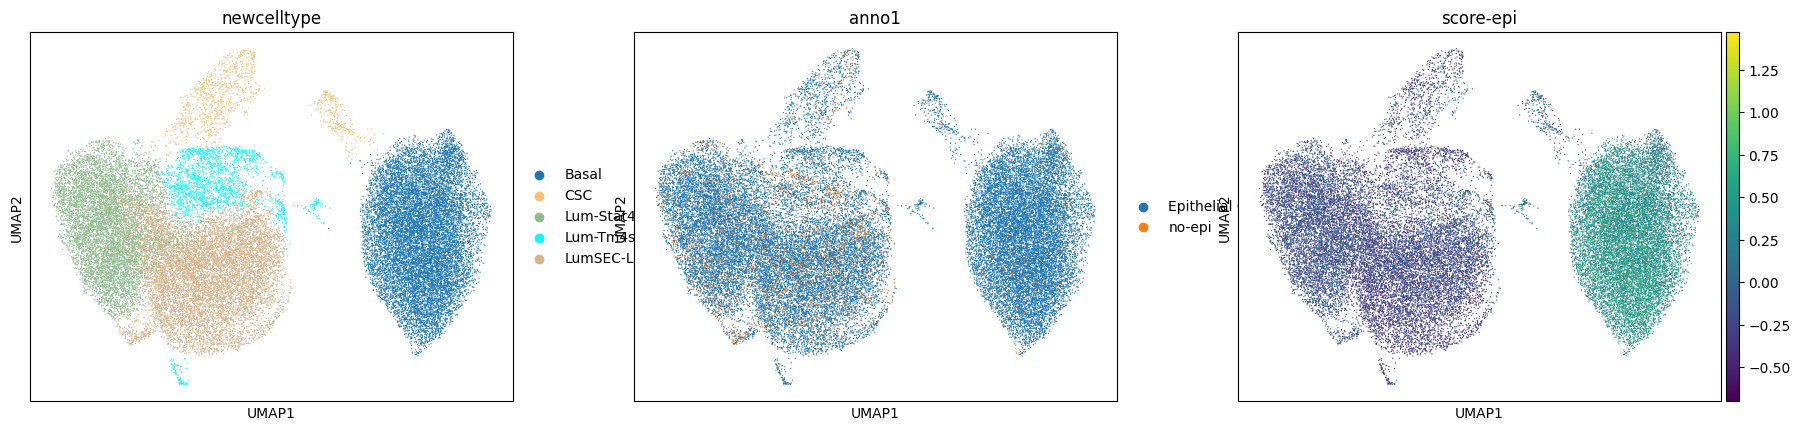

In [3]:
import scanpy as sc
adata=sc.read_h5ad('D:/Data/R-CG_cleaned_filter.h5ad')
sc.pl.umap(adata,color=['newcelltype','anno1','score-epi'])

In [4]:
import pandas as pd
import scanpy as sc

# 修改为你的路径
pkl_in = "./v9_index_filter.pkl"
adata_in = "D:/Data/M-MG.h5ad"

# 读取
df = pd.read_pickle(pkl_in)
adata = sc.read_h5ad(adata_in)

# 统一转为字符串比较（避免同值但 dtype 不同导致假不匹配）
ad_idx = pd.Index(adata.obs_names.astype(str), name="index")
pk_idx = pd.Index(df.index.astype(str), name="index")

# 统计
n_ad = ad_idx.size
n_pk = pk_idx.size
matched = ad_idx.intersection(pk_idx).size
unmatched_ad = ad_idx.difference(pk_idx).size
extra_pk = pk_idx.difference(ad_idx).size
dup_ad = n_ad - ad_idx.nunique()
dup_pk = n_pk - pk_idx.nunique()
same_order = (n_ad == n_pk) and ad_idx.equals(pk_idx)  # 是否长度一致且顺序完全相同

print({
    "adata_total": n_ad,
    "pkl_total": n_pk,
    "matched": matched,
    "unmatched_in_adata": unmatched_ad,
    "extra_in_pkl": extra_pk,
    "duplicate_index_in_adata": dup_ad,
    "duplicate_index_in_pkl": dup_pk,
    "coverage_%": round(matched / n_ad * 100, 2) if n_ad else 0.0,
    "same_order": same_order
})

# 如需查看少量未匹配项（仅调试用），解开下面两段注释：
# if unmatched_ad:
#     print("Unmatched (in adata only) head10:", list(ad_idx.difference(pk_idx))[:10])
# if extra_pk:
#     print("Extra (in PKL only) head10:", list(pk_idx.difference(ad_idx))[:10])


{'adata_total': 118430, 'pkl_total': 612308, 'matched': 77121, 'unmatched_in_adata': 41309, 'extra_in_pkl': 535187, 'duplicate_index_in_adata': 0, 'duplicate_index_in_pkl': 0, 'coverage_%': 65.12, 'same_order': False}
